# Medidas de Variabilidad

Rango, IQR, varianza muestral, desviación estándar y coeficiente de variación (CV) de las variables cuantitativas, sobre el dataset crudo y el procesado y por grupo de `sufrio_violencia_pareja`. Las funciones están en `src/eda/medidas_variabilidad.py`.

## 1. Configuración

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

from src.eda.medidas_variabilidad import COL_GRUPO, COLUMNAS, FUENTES, calcular_medidas_variabilidad
from src.visualization.graficas import aplicar_estilo, guardar_figura

aplicar_estilo()
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(200)

polars.config.Config

## 2. Carga de datos

Las rutas vienen de `config/rutas.py`.

In [2]:
datos = {etiqueta: pl.read_csv(ruta) for etiqueta, ruta in FUENTES.items()}
for etiqueta, df in datos.items():
    print(f"{etiqueta:10s} {df.shape}")

crudo      (110127, 24)
procesado  (105753, 25)


## 3. Medidas de variabilidad

### 3.1 Población total (crudo y procesado)

In [3]:
tabla = pl.concat([
    calcular_medidas_variabilidad(df, COLUMNAS).select(pl.lit(etiqueta).alias("dataset"), pl.all())
    for etiqueta, df in datos.items()
])
tabla

dataset,variable,n,media,minimo,maximo,rango,q1,q3,iqr,varianza_muestral,desviacion_estandar,cv_%
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""crudo""","""edad_primer_union""",24560,13.198453,0.0,99.0,99.0,2.0,17.0,15.0,380.598996,19.508947,147.812375
"""crudo""","""num_hijos""",90691,2.517571,1.0,4.0,3.0,1.0,3.0,2.0,1.408741,1.186904,47.144818
"""crudo""","""ingreso_pareja""",48980,86351.046039,0.0,9.99999e5,9.99999e5,1000.0,6000.0,5000.0,7.5458e10,274695.849354,318.115254
"""procesado""","""edad_primer_union""",23662,10.031062,0.0,76.0,76.0,2.0,15.0,13.0,114.904703,10.719361,106.861672
"""procesado""","""num_hijos""",105753,2.252844,1.0,4.0,3.0,1.0,3.0,2.0,1.494082,1.222327,54.257051
"""procesado""","""ingreso_pareja""",47951,4980.923505,0.0,999997.0,999997.0,1000.0,4000.0,3000.0,1.3535e9,36789.590721,738.609832


### 3.2 Por grupo de violencia de pareja (procesado)

`sufrio_violencia_pareja`: 1 = sí, 0 = no.

In [4]:
por_grupo = calcular_medidas_variabilidad(datos["procesado"], COLUMNAS, grupo=COL_GRUPO).sort("variable", COL_GRUPO)
por_grupo

sufrio_violencia_pareja,variable,n,media,minimo,maximo,rango,q1,q3,iqr,varianza_muestral,desviacion_estandar,cv_%
i64,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,"""edad_primer_union""",15195,10.034156,0.0,76.0,76.0,2.0,15.0,13.0,117.353644,10.832989,107.961135
1,"""edad_primer_union""",8467,10.025511,0.0,72.0,72.0,2.0,15.0,13.0,110.523091,10.512996,104.86245
0,"""ingreso_pareja""",37995,5115.330938,0.0,999997.0,999997.0,1000.0,4500.0,3500.0,1.3624e9,36911.262442,721.581123
1,"""ingreso_pareja""",9956,4467.985536,0.0,999997.0,999997.0,848.75,3200.0,2351.25,1.3191e9,36318.775548,812.866901
0,"""num_hijos""",86551,2.22812,1.0,4.0,3.0,1.0,3.0,2.0,1.488781,1.220156,54.761694
1,"""num_hijos""",19202,2.364285,1.0,4.0,3.0,1.0,3.0,2.0,1.502881,1.225921,51.851645


## 4. Gráficas

### 4.1 CV crudo vs procesado

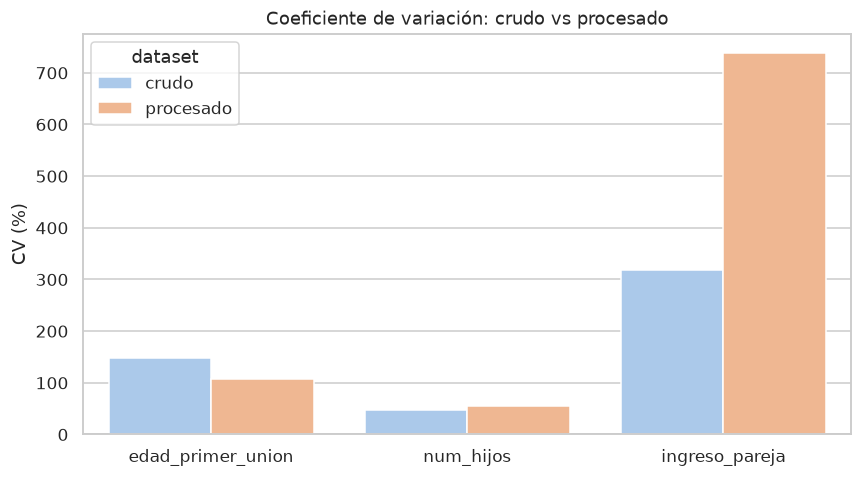

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=tabla.to_pandas(), x="variable", y="cv_%", hue="dataset", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("CV (%)")
ax.set_title("Coeficiente de variación: crudo vs procesado")
fig.tight_layout()
guardar_figura(fig, "var_cv_crudo_vs_procesado")
plt.show()

### 4.2 Distribución por grupo de violencia (procesado)

El ingreso se muestra en escala logarítmica (sin los ingresos de 0).

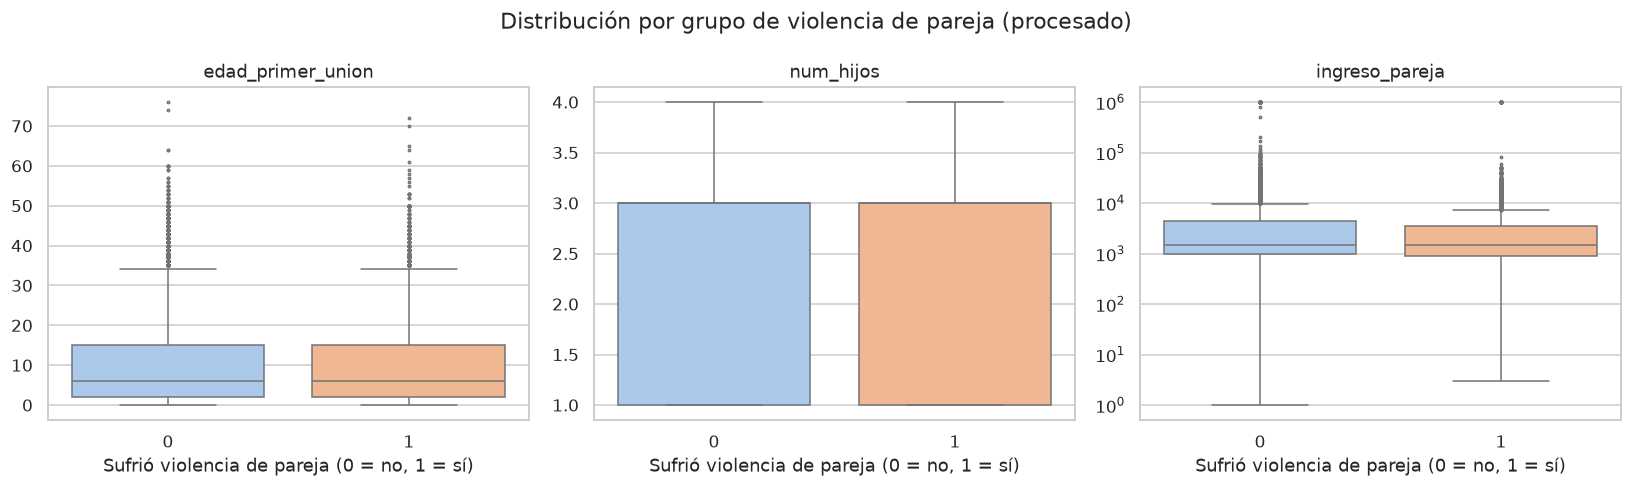

In [6]:
df = datos["procesado"].to_pandas()
fig, axes = plt.subplots(1, len(COLUMNAS), figsize=(15, 4.5))
for ax, variable in zip(axes, COLUMNAS):
    sub = df[df[variable] > 0] if variable == "ingreso_pareja" else df
    sns.boxplot(data=sub, x=COL_GRUPO, y=variable, hue=COL_GRUPO, legend=False, ax=ax, fliersize=1.5)
    ax.set_title(variable)
    ax.set_xlabel("Sufrió violencia de pareja (0 = no, 1 = sí)")
    ax.set_ylabel("")
    if variable == "ingreso_pareja":
        ax.set_yscale("log")
fig.suptitle("Distribución por grupo de violencia de pareja (procesado)")
fig.tight_layout()
guardar_figura(fig, "var_boxplot_por_grupo")
plt.show()

## 5. Interpretación

- **edad_primer_union**: al quitar los códigos 98/99, el rango baja de 99 a 76, la desviación estándar de 19.51 a 10.72, el CV de 147.81 % a 106.86 % y el IQR de 15 a 13. El CV sigue arriba de 100 %: la variabilidad es muy alta.
- **num_hijos**: variabilidad moderada; el rango se mantiene en 3 y la desviación estándar apenas cambia (1.19 → 1.22). El CV sube de 47.14 % a 54.26 % porque la imputación bajó la media.
- **ingreso_pareja**: la desviación estándar baja de 274,695.85 a 36,789.59, pero el CV sube de 318.12 % a 738.61 % porque la media cae más (de 86,351 a 4,980.92). Aun limpio, el ingreso es muy desigual; el IQR (de $5,000 a $3,000) es la medida robusta.
- **Por grupo**: edad e hijos tienen variabilidad parecida en ambos grupos. En el ingreso, el grupo que reportó violencia tiene CV más alto (812.87 % contra 721.58 %) e IQR más bajo ($2,351 contra $3,500).